In [6]:
from astroquery.gaia import Gaia
import pandas as pd
#query gaia data
query = """
SELECT TOP 100 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND num_clean_epochs_g > 40
ORDER BY num_clean_epochs_g DESC
"""

job = Gaia.launch_job_async(query)#asynchronous to not overload server
rrl_results = job.get_results()
df_rrl = rrl_results.to_pandas()#convert to pandas df
source_ids = df_rrl['source_id'].tolist()#get list of source ids

light_curves = {}

# I was getting an Error 500 from overloading the server, so I fixed it by creating a loop that queries 1 light curve at a time and then appends it to the pandas dataframe
for i, source_id in enumerate(source_ids):
    try:
        # distinct=True is required to get the specific light curve
        datalink = Gaia.load_data(ids=[source_id], data_release='Gaia DR3', 
                                  retrieval_type='EPOCH_PHOTOMETRY', 
                                  format='votable')
        
        # i only need the first table from the dictionary it returns
        dl_keys = list(datalink.keys())
        if len(dl_keys) > 0:
            lc_table = datalink[dl_keys[0]][0].to_table() # Convert to Astropy Table
            light_curves[source_id] = lc_table.to_pandas() # Store as Pandas
            
            if i % 10 == 0: print(f"Fetched {i+1}/100...")
            
    except Exception as e:
        print(f"Failed to fetch {source_id}: {e}")

print(f"Successfully downloaded {len(light_curves)} light curves.")

INFO: Query finished. [astroquery.utils.tap.core]
Fetched 1/100...
Fetched 11/100...
Fetched 21/100...
Fetched 31/100...
Fetched 41/100...
Fetched 51/100...
Fetched 61/100...
Fetched 71/100...
Fetched 81/100...
Fetched 91/100...
Successfully downloaded 100 light curves.


In [8]:
print(df_rrl.head(10))

          solution_id            source_id        pf      pf_error  p1_o  \
0  375316653866487565  5284173207165634048  0.675420  1.145270e-05   NaN   
1  375316653866487565  5284160459706483200  0.594031  2.560468e-06   NaN   
2  375316653866487565  5284187019781084672  0.759014  4.346572e-06   NaN   
3  375316653866487565  5284172756184089344  0.644892  2.140856e-06   NaN   
4  375316653866487565  4659724368673132416  0.570075  1.484097e-06   NaN   
5  375316653866487565  4659723200444651648  0.627345  1.157564e-05   NaN   
6  375316653866487565  5284161589266997632  0.697379  4.213670e-06   NaN   
7  375316653866487565  4659759557323962752  0.652355  6.628113e-06   NaN   
8  375316653866487565  5284173550756283008  0.532471  6.337411e-07   NaN   
9  375316653866487565  5476378315113644416  0.657836  2.026528e-06   NaN   

   p1_o_error      epoch_g  epoch_g_error     epoch_bp  epoch_bp_error  ...  \
0         NaN  1664.714726   1.619656e-05  1664.725090        0.000043  ...   
1    

In [10]:
print(lc_data.columns)

Index(['transit_id', 'g_transit_time', 'g_transit_flux',
       'g_transit_flux_error', 'g_transit_flux_over_error', 'g_transit_mag',
       'bp_obs_time', 'bp_flux', 'bp_flux_error', 'bp_flux_over_error',
       'bp_mag', 'rp_obs_time', 'rp_flux', 'rp_flux_error',
       'rp_flux_over_error', 'rp_mag', 'variability_flag_g_reject',
       'variability_flag_bp_reject', 'variability_flag_rp_reject',
       'g_other_flags', 'bp_other_flags', 'rp_other_flags',
       'rejected_by_photometry'],
      dtype='object')


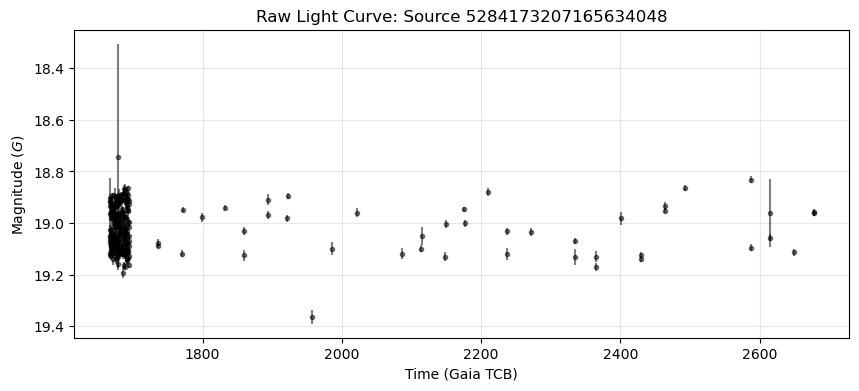

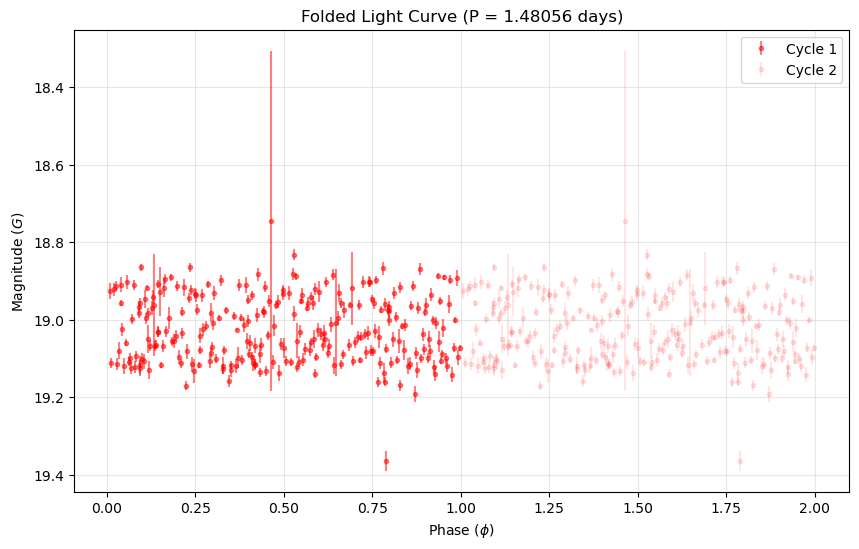

In [11]:
import matplotlib.pyplot as plt
import numpy as np

#  selecting first star from table
target_index = 0
star_row = df_rrl.iloc[target_index]
source_id = star_row['source_id']

period = 1.0 / star_row['pf'] #retrieving period data, gaia gives pf (freq) so period = 1/pf

lc_data = light_curves[source_id] #retrieving lc

#i pulled the whole table from gaia db so now im cleaning the g_band data
g_band_data = lc_data[['g_transit_time', 'g_transit_mag', 'g_transit_flux_over_error']].dropna() 
g_band_data = g_band_data.rename(columns={
    'g_transit_time': 'time',
    'g_transit_mag': 'mag',
    'g_transit_flux_over_error': 'flux_over_error'
})

# magnitude  error derived from flux/error ratio provided by gaia 
# i took the derivative of magnitude with respect to flux to derive the 1.0857 term
# (d/dF)m= (d/dF)−2.5log10*(F)+C -> 2.5/ln(10) = 1.0857
g_band_data['error'] = 1.0857 / g_band_data['flux_over_error']

# Phase = (Time / Period) - IntegerPart(Time / Period)
g_band_data['phase'] = (g_band_data['time'] % period) / period

# --- Raw light curve plot ---
plt.figure(figsize=(10, 4))
plt.errorbar(g_band_data['time'], g_band_data['mag'], 
             yerr=g_band_data['error'], 
             fmt='.', color='black', alpha=0.5, label='G-Band')

plt.gca().invert_yaxis() # inverting y axis b/c brighter stars have lower magnitdues (thanks hipparchus/contemporary astronomers)
plt.title(f"Raw Light Curve: Source {source_id}")
plt.xlabel("Time (Gaia TCB)")
plt.ylabel("Magnitude ($G$)")
plt.grid(True, alpha=0.3)
plt.show()
# --- Phase folded plot ---
plt.figure(figsize=(10, 6))

# i plotted 2 cycles because it created a more visually appealing/digestable graph
plt.errorbar(g_band_data['phase'], g_band_data['mag'], 
             yerr=g_band_data['error'], fmt='.', color='red', alpha=0.5, label='Cycle 1')

plt.errorbar(g_band_data['phase'] + 1.0, g_band_data['mag'], 
             yerr=g_band_data['error'], fmt='.', color='red', alpha=0.1, label='Cycle 2')

plt.gca().invert_yaxis()
plt.title(f"Folded Light Curve (P = {period:.5f} days)")
plt.xlabel("Phase ($\phi$)")
plt.ylabel("Magnitude ($G$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Gaia Reported Period: 1.48056 days
Lomb-Scargle Estimated Period: 0.67544 days


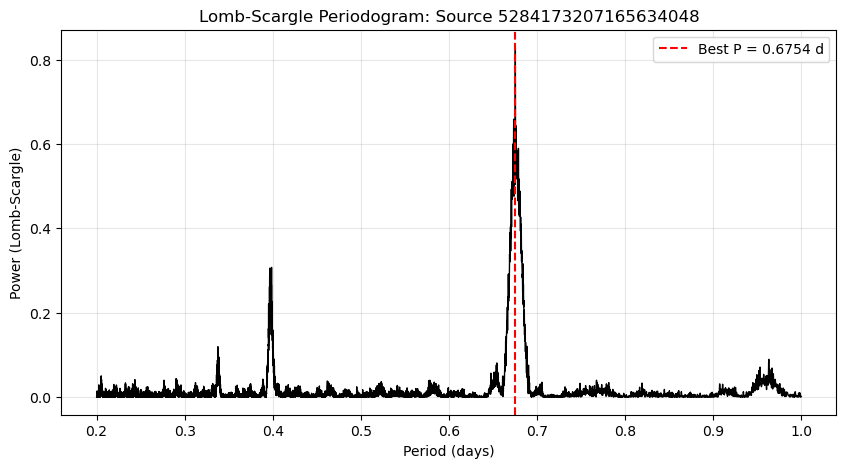

In [13]:
from astropy.timeseries import LombScargle

#Lomb Scargle Periodigrams (goofy name lol) are a method of estimating the period of an oscillating data set. 
#essentially they try to fit multiple sine waves of varying frequencies to the data set
# the sine wave that tracks the best (minimizes variance) is considered the best fit. You can then use the period of this sine wave to approximate teh period of your data!
# the periodogram is plotted w/ sin freq on x-axis and power (how good that sine wave fit to the data) on the y-axis

#frequency grid
min_freq = 1.0 / 1.0  # 1 day
max_freq = 1.0 / 0.2  # 0.2 days

# Lomb-Scargle Periodogram
# parameters are time (t) magnitude (y), and  the Error (dy) (optional)
frequency, power = LombScargle(g_band_data['time'], 
                               g_band_data['mag'], 
                               g_band_data['error']).autopower(minimum_frequency=min_freq,
                                                               maximum_frequency=max_freq)

# finding which sine wave fits the data the best
best_freq_index = np.argmax(power)
best_freq = frequency[best_freq_index]
best_period = 1.0 / best_freq

print(f"Gaia Reported Period: {period:.5f} days")
print(f"Lomb-Scargle Estimated Period: {best_period:.5f} days")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(1.0 / frequency, power, color='black', lw=1)

# Mark the best peak
plt.axvline(best_period, color='red', linestyle='--', label=f'Best P = {best_period:.4f} d')

plt.title(f"Lomb-Scargle Periodogram: Source {source_id}")
plt.xlabel("Period (days)")
plt.ylabel("Power (Lomb-Scargle)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()